Importation des librairies

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

from import_dataset import load_dataset

Chargement du Dataset

In [3]:
#BASE_DIR = os.path.dirname(os.path.abspath(__file__)) le __file__ fait planter le code dans un script python, mais dans un notebook il n'est pas défini, du coup on utilise os.getcwd() pour prendre le répertoire courant du notebook
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "Dataset", "Domain1_csv")

#print(len(os.listdir(DATA_DIR))) validation que tous les chiffiers ont été chargés

def load_dataset(data_dir):
    all_data = [] #liste qui contiendra chaque dataframe de chaque fichier csv lu et nettoyé

    #print(os.listdir(DATA_DIR)) print tout les fichier du dossier Dataset/Domain1_csv 
    #pour vérifier que les fichiers sont bien là

    for file in os.listdir(DATA_DIR):
        if not file.endswith(".csv"):
            continue
        
        name = file.replace(".csv", "").replace("Subject", "") #enlève l'extension .csv et le préfixe "Subject" pour ne garder que les chiffres
        parts = name.split("-") #sépare les chiffres en trois parties : subject_id, digit, repetition. Exemple : "Subject1-0-1.csv" devient ["1", "0", "1"]

        if len(parts) != 3:
            print(f"Filename {file} does not match expected format. Skipping.")
            continue
    
        subject_id = int(parts[0]) #le premier chiffre correspond à l'identifiant du sujet
        digit= int(parts[1]) #le deuxième chiffre correspond au chiffre que le sujet doit signer (de 0 à 9)
        repetition = int(parts[2]) #le troisième chiffre correspond à la répétition de la même séquence de signes (de 1 à 3)

        filepath = os.path.join(DATA_DIR, file) 
        df = pd.read_csv(filepath, skiprows=[0], names=['x','y','z','t']) 
    
        df['subject_id'] = subject_id 
        df['digit'] = digit
        df['repetition'] = repetition

        all_data.append(df)
    return all_data

dataset = pd.concat(load_dataset(DATA_DIR), ignore_index=True) 

print(f"{len(dataset)} fichiers chargés .") 
print(f"Dimension du dataset : {dataset.shape}")

print(dataset.head())

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
dataset.to_csv(os.path.join(BASE_DIR, "Dataset", "Aggregated_csv", "Domain1_processed_dataset.csv"), index=False) 

#-------------------------------------------
#solution pour charger les data du csv en évitant l'import d'une ligne 0 <x> <y> <z> <t> skiprows=[0]

#df = pd.read_csv(os.path.join(DATA_DIR, "Subject1-0-1.csv"), skiprows=[0], names=['x','y','z','t'])
#print(df.head())

85095 fichiers chargés .
Dimension du dataset : (85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1


Sous-échantillonnage

Sous-echantillonnage des données...


C:\Users\lechef\AppData\Local\Temp\ipykernel_20404\3480968570.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['subject_id', 'digit', 'repetition'])


Terminé !
Points originaux     : 85,095
Points sous-échant.  : 36,912
Réduction effective  : 56.6%

 Aperçu des ratios de réduction par groupe :
       subject_id       digit  repetition  n_original  n_downsampled  \
count  764.000000  764.000000  764.000000  764.000000     764.000000   
mean     5.945026    4.286649    5.413613   94.986911      48.314136   
std      2.824182    2.910690    2.881063   20.939589      10.451699   
min      1.000000    0.000000    1.000000   66.000000      34.000000   
25%      4.000000    2.000000    3.000000   81.000000      41.000000   
50%      6.000000    4.000000    5.000000   90.000000      46.000000   
75%      8.000000    6.000000    8.000000  105.250000      53.250000   
max     10.000000    9.000000   10.000000  190.000000      96.000000   

            ratio  
count  764.000000  
mean     0.509066  
std      0.004164  
min      0.493506  
25%      0.505618  
50%      0.508265  
75%      0.511905  
max      0.522388  
Subject ID: 1, Digit: 0, N

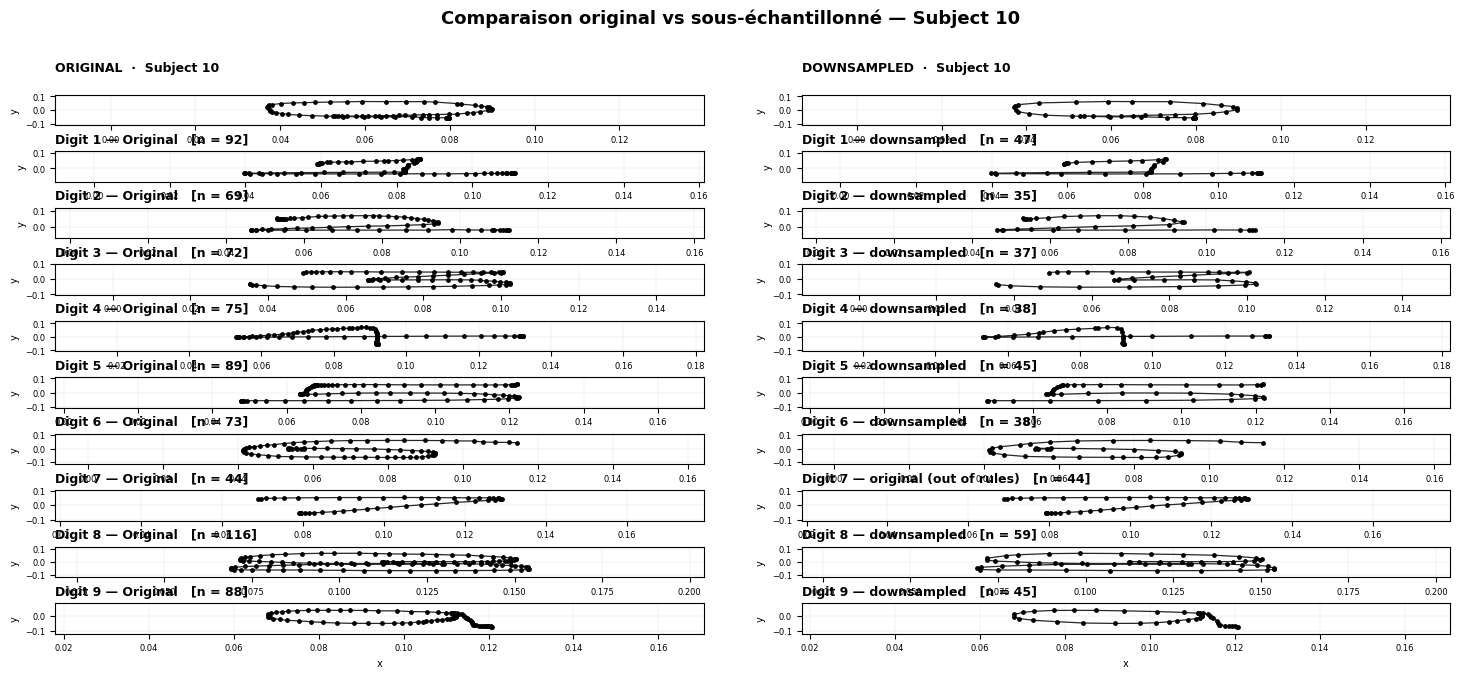

Affichage terminé.


In [4]:
df = dataset.copy() # pour éviter de modifier le dataset original

def downsample_data(group,factor=2):

    # Supprime les lignes où t n'est pas numérique
    group = group[pd.to_numeric(group['t'], errors='coerce').notna()] 

    group['t'] = group['t'].astype(float)

    group = group.sort_values('t').reset_index(drop=True) 
    
    #print(group.head())

    N= len(group)
    if N<66: #datapoints min = 32 donc on downsample à partir de 66 points (32*2) pour éviter de perdre trop d'information
        group["downsampled"] = False 
        return group

    t_first = int(group['t'].iloc[0]) 
    t_last = int(group['t'].iloc[-1])
    
    duration = t_last - t_first

    if duration == 0: 
        return group
    
    f_original = N / duration 
    f_new = f_original / factor 

    dt_new = 1.0 / f_new

    target_times = np.arange(t_first, t_last + dt_new * 0.5, dt_new) 
    t_values = group['t'].values 
    chosen_idx= set()

    for t_target in target_times: 
        idx = np.argmin(np.abs(t_values - t_target))
        chosen_idx.add(idx)

    result = group.iloc[sorted(chosen_idx)].reset_index(drop=True)

    if not (32<= len(result) <= 120):
        group["downsampled"] = False
        return group
    
    result["downsampled"] = True

    return result 

print("Sous-echantillonnage des données...")

df_result = (
    df.groupby(['subject_id', 'digit', 'repetition']) 
    .apply(downsample_data)
    .reset_index(drop=True)
)

df_downsampled = df_result[df_result['downsampled'] == True].drop(columns=['downsampled'])

original_count = len(df) 
downsampled_count = len(df_downsampled)
reduction = (1-downsampled_count/original_count)*100

print(f"Terminé !")
print(f"Points originaux     : {original_count:,}")
print(f"Points sous-échant.  : {downsampled_count:,}")
print(f"Réduction effective  : {reduction:.1f}%")

# --- Vérification par groupe ---
summary = df.groupby(["subject_id", "digit", "repetition"]).size().reset_index(name="n_original")
summary_new = df_downsampled.groupby(["subject_id", "digit", "repetition"]).size().reset_index(name="n_downsampled")

summary["was_downsampled"] = df_result.groupby(["subject_id", "digit", "repetition"])["downsampled"].first().values

summary = summary.merge(summary_new, on=["subject_id", "digit", "repetition"])
summary["ratio"] = summary["n_downsampled"] / summary["n_original"]

skipped = (~summary["was_downsampled"]).sum()
print("\n Aperçu des ratios de réduction par groupe :")
print(summary.describe())

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
#df_downsampled.to_csv(os.path.join(BASE_DIR, "Dataset", "Domain1_aggregated_csv", "Domain1_downsampled_dataset.csv"), index=False)

# prendre un subset 
subset = df[(df['subject_id'] == 1) & (df['digit'] == 0)]

for (subject_id, digit,rep), group in subset.groupby(['subject_id', 'digit', 'repetition']):
   print(f"Subject ID: {subject_id}, Digit: {digit}, Number of rows: {len(group)}")


# code pour afficher les points avant et après le sous-échantillonnage pour un groupe spécifique (par exemple, subject_id=1, digit=0)

Subject = 1 
Line_color = 'black'

Digits = sorted(df['digit'].unique())
N_rows = len(Digits)
N_columns = 2



def plot_xy_grid(subject=Subject, line_color=Line_color):
    fig, axes = plt.subplots(N_rows, N_columns, figsize=(18, 7))
    
    for row_idx, digit in enumerate(Digits):

         # Sélection du groupe original
        df_group = df[
            (df['subject_id'] == subject) &
            (df['digit'] == digit)
        ]

        rep_counts = df_group.groupby("repetition").size()
        best_rep = rep_counts.idxmin() # répétition avec le moins de points (plus représentative du sous-échantillonnage)

        # données originales pour la répétition choisie
        df_orig= df_group[df_group['repetition'] == best_rep].sort_values('t')
        n_orig= len(df_orig)

        # données sous-échantillonnées pour le même groupe
        df_downsampled = df_result[
            (df_result['subject_id'] == subject) &
            (df_result['digit'] == digit) &
            (df_result['repetition'] == best_rep)
        ].sort_values('t')
        n_downsampled = len(df_downsampled)

        was_ds = df_downsampled['downsampled'].iloc[0] if len(df_downsampled)>0 else False

        for col in ["x", "y"]:
            df_orig[col] = df_orig[col].astype(float)
            df_downsampled[col] = df_downsampled[col].astype(float)

        # Limite d'axes (référence commune pour les deux subplots)
        x_min = min(df_orig["x"].min(), df_downsampled["x"].min())
        x_max = max(df_orig["x"].max(), df_downsampled["x"].max())
        y_min = min(df_orig["y"].min(), df_downsampled["y"].min())
        y_max = max(df_orig["y"].max(), df_downsampled["y"].max())
        margin = 0.05

        # --- Subplot gauche : original ---
        ax_left  = axes[row_idx, 0]
        ax_left.plot(df_orig["x"].values, df_orig["y"].values,
                 color=line_color, linewidth=0.9, alpha=0.85)
        ax_left.scatter(df_orig["x"].values, df_orig["y"].values,
                    color=line_color, s=6, zorder=3)
        ax_left.set_title(
            f"Digit {digit} — Original   [n = {n_orig}]",
            fontsize=9, fontweight="bold", loc="left"
        )
        ax_left.set_xlabel("x", fontsize=7)
        ax_left.set_ylabel("y", fontsize=7)
        ax_left.tick_params(labelsize=6)
        ax_left.grid(True, linewidth=0.3, alpha=0.4)

        ax_left.set_xlim(x_min - margin, x_max + margin)
        ax_left.set_ylim(y_min - margin, y_max + margin)

        # --- Subplot droite : sous-échantillonné ---
        ax_right = axes[row_idx, 1]
        ax_right.plot(df_downsampled["x"].values, df_downsampled["y"].values,
                  color=line_color, linewidth=0.9, alpha=0.85)
        ax_right.scatter(df_downsampled["x"].values, df_downsampled["y"].values,
                     color=line_color, s=6, zorder=3)

        label_ds = "downsampled" if was_ds else "original (out of rules)"
        ax_right.set_title(
            f"Digit {digit} — {label_ds}   [n = {n_downsampled}]",
            fontsize=9, fontweight="bold", loc="left"
        )
        ax_right.set_xlabel("x", fontsize=7)
        ax_right.set_ylabel("y", fontsize=7)
        ax_right.tick_params(labelsize=6)
        ax_right.grid(True, linewidth=0.3, alpha=0.4)

        ax_right.set_xlim(x_min - margin, x_max + margin)
        ax_right.set_ylim(y_min - margin, y_max + margin)

        
    # --- En-têtes colonnes ---
    orig_title= axes[0, 0].get_title()
    down_title = axes[0, 1].get_title()

    axes[0, 0].set_title(
        f"ORIGINAL  ·  Subject {subject}\n" + axes[0, 0].get_title(),
        fontsize=9, fontweight="bold", loc="left"
    )
    axes[0, 1].set_title(
        f"DOWNSAMPLED  ·  Subject {subject}\n" + axes[0, 1].get_title(),
        fontsize=9, fontweight="bold", loc="left"
    )

    plt.suptitle(
        f"Comparaison original vs sous-échantillonné — Subject {subject}",
        fontsize=13, fontweight="bold", y=1.002
    )
    plt.subplots_adjust(hspace=0.85)   # espace vertical entre lignes (0.0 à 1.0)
    plt.subplots_adjust(wspace=0.15)   # espace horizontal entre colonnes

    plt.show()
    print("Affichage terminé.")


plot_xy_grid(subject=10)


Méthode du coude

Standardisation individuelle des gestes en cours...


C:\Users\lechef\AppData\Local\Temp\ipykernel_20404\1500931441.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_downsampled = df_downsampled.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group)


Prêt ! 36912 points 3D vont être analysés.
K-Means : Test des k de 2 à 30 ...


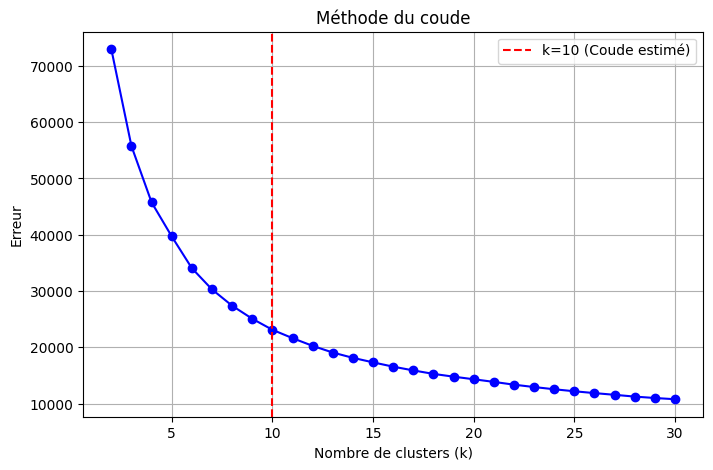

In [5]:
print("Standardisation individuelle des gestes en cours...")

# 1. La standardisation PAR GESTE 
def standardize_group(group):
    coords = group[['x', 'y', 'z']].values 
    gravity_center = np.mean(coords, axis=0)
    std = np.std(coords, axis=0)
    std[std == 0] = 1 # Sécurité pour éviter ladivision par zéro
    
    coords_std = (coords - gravity_center) / std
    
    # On ajoute directement les colonnes au groupe
    group['x_std'] = coords_std[:, 0]
    group['y_std'] = coords_std[:, 1]
    group['z_std'] = coords_std[:, 2]
    return group

# On l'applique sur chaque geste du df_downsampled 

df_downsampled = df_downsampled.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group) 

# 2. Extraction des points 

points_3d = df_downsampled[['x_std', 'y_std', 'z_std']].values # on prend les colonnes standardisées pour faire du clustering
print(f"Prêt ! {points_3d.shape[0]} points 3D vont être analysés.")

# 3. Méthode du coude
def plot_elbow_method(X, max_k=30): 
    errors = []
    k_values = range(2, max_k + 1)
    
    print(f"K-Means : Test des k de 2 à {max_k} ...")
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X) 
        errors.append(kmeans.inertia_) # inertia_ est la somme des distances au carré entre les points et leur centre de cluster (plus c'est bas, mieux c'est)

    plt.figure(figsize=(8,5))
    plt.plot(k_values, errors, marker='o', color='b')
    
    # On ajoute une ligne pointillée sur k=10 pour le mettre en évidence
    plt.axvline(x=10, color='r', linestyle='--', label='k=10 (Coude estimé)')
    
    plt.title('Méthode du coude')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel("Erreur")
    plt.legend()
    plt.grid(True)
    plt.show()

# On lance le test !
plot_elbow_method(points_3d)

In [6]:
print("Création de l'alphabet et traduction...")

# 1. Entraînement du modèle définitif avec le k=10 (choisi à partir de la méthode du coude)
k_optimal = 10
points_3d = df_downsampled[['x_std', 'y_std', 'z_std']].values

print(f"Apprentissage des {k_optimal} lettres de l'alphabet spatial...")
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_final.fit(points_3d)

# 2. La fonction de traduction (de points 3D vers du Texte)
def traduire_en_lettres(group):
    # On extrait les points standardisés du geste
    coords = group[['x_std', 'y_std', 'z_std']].values
    
    # Le K-Means attribue chaque point à son cluster le plus proche (de 0 à 12)
    labels = kmeans_final.predict(coords)
    
    # On transforme le numéro en lettre (0 -> A, 1 -> B, ..., 12 -> M)
    # L'astuce : chr(65) donne 'A' en informatique (code ASCII)
    lettres = [chr(65 + label) for label in labels]
    
    # On colle toutes les lettres pour faire un seul mot (ex: "AABBCCC...")
    mot = "".join(lettres)
    
    # On retourne une petite boîte contenant notre mot
    return pd.Series({'mot_traduit': mot})

print("Traduction des gestes en texte ...")

# 3. Application de la traduction geste par geste
# On reprend notre chef d'orchestre groupby pour ne pas mélanger les gestes !
df_mots = df_downsampled.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres).reset_index()

# 4. Sauvegarde du Dictionnaire Final
output_dir = os.path.join(BASE_DIR, "Dataset", "Aggregated_csv")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Domain1_dictionnaire_mots.csv")

df_mots.to_csv(output_path, index=False)

print(f"TERMINÉ ! Le dictionnaire est sauvegardé ici : {output_path}")
print("\n Aperçu de tes données (prêtes pour l'Edit Distance) :")
print(df_mots.head(10))

Création de l'alphabet et traduction...
Apprentissage des 10 lettres de l'alphabet spatial...
Traduction des gestes en texte ...
TERMINÉ ! Le dictionnaire est sauvegardé ici : c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Gesture-Recognition-Project-main\Dataset\Aggregated_csv\Domain1_dictionnaire_mots.csv

 Aperçu de tes données (prêtes pour l'Edit Distance) :
   subject_id  digit  repetition  \
0           1      0           1   
1           1      0           2   
2           1      0           3   
3           1      0           4   
4           1      0           5   
5           1      0           6   
6           1      0           7   
7           1      0           8   
8           1      0           9   
9           1      0          10   

                                         mot_traduit  
0  AAAAAAAAAAAHHHHHHHHHHCCCCCCCCCFFFFFBBBBBBBBGGG...  
1  GGGGGGEEEEEEAAAAHHHHHHHHHHHHHCCCCCCCCCFFFFBBBB...  
2  GGGGGGGGEEEEEEAAAAAAAAHHHHHHHHHHHHHHHHHHCCCCCC...  


C:\Users\lechef\AppData\Local\Temp\ipykernel_20404\581073058.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mots = df_downsampled.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres).reset_index()


In [7]:
def edit_distance(w1,w2):

    # empty matrice
    m,n = len(w1),len(w2)
    df =  np.zeros((m+1,n+1))
    #print(df)

    # initialisation 1st row 1st column
    for i in range(m+1):
        df[i][0] = i
    for j in range(n+1):
        df[0][j] = j
    #print(df)

    # compute the edit-distance

    for i in range(1,m+1): 
        for j in range(1,n+1):
            if w1[i-1] == w2[j-1]: # on doit retirer 1 à i et j parce que les indices de la matrice sont décalés à cause de la colonne et la ligne d'initiation 
                df[i][j] = df[i-1][j-1]
            else :
                add = df[i][j-1] +1 #add
                delete = df[i-1][j] +1 #del
                replace = df[i-1][j-1] +1 #sub
                df[i][j] = min(add,delete,replace)
    print(df)
    (print(f"Edit-distance entre",w1, "et", w2, " est de ", df[m][n]))
    return df[m][n]

cost = edit_distance('arbre','arbitrage')

[[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [1. 0. 1. 2. 3. 4. 5. 6. 7. 8.]
 [2. 1. 0. 1. 2. 3. 4. 5. 6. 7.]
 [3. 2. 1. 0. 1. 2. 3. 4. 5. 6.]
 [4. 3. 2. 1. 1. 2. 2. 3. 4. 5.]
 [5. 4. 3. 2. 2. 2. 3. 3. 4. 4.]]
Edit-distance entre arbre et arbitrage  est de  4.0
